In [15]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [16]:
input_dir = r"C:\Users\admin\Downloads\TEST_DOCUMENT"
output_dir = r"C:\Users\admin\Downloads\TEST_DOCUMENT_NEW"
ct0 = np.fromfile(r"C:\Users\admin\Downloads\TEST_DOCUMENT\CT_new.raw", dtype="float32").reshape(300,512,512)
ct = ct0.copy()


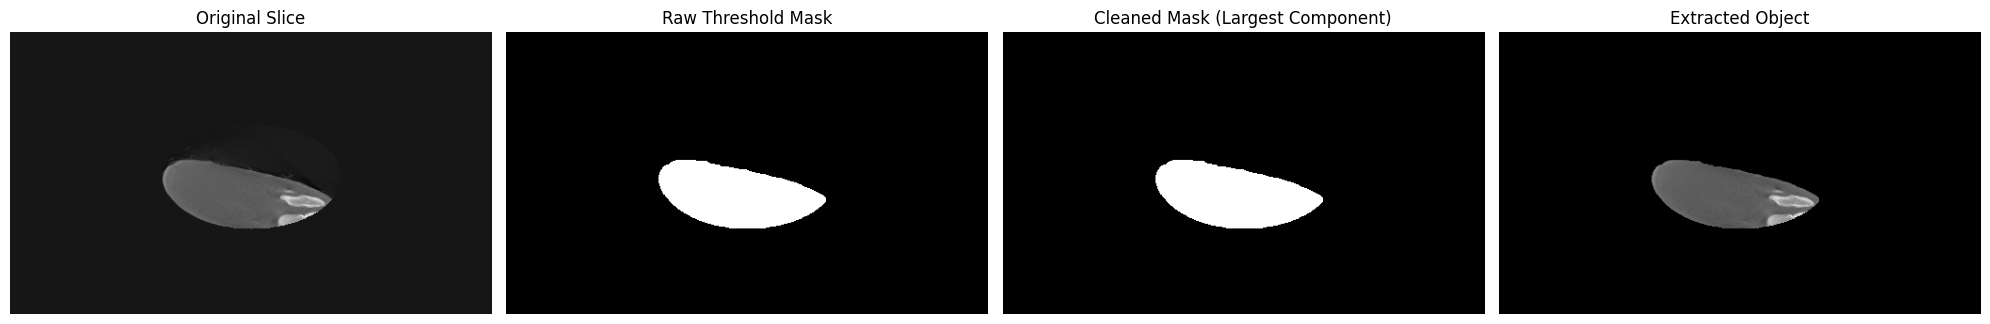

In [25]:
img = cv2.normalize(ct0[:, 100, :], None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# 方法1: 简单阈值分割（适合对比度明显的情况）
_, mask = cv2.threshold(img, 30, 255, cv2.THRESH_BINARY)

# 方法2: Otsu 自动阈值（推荐）
_, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 形态学操作：填充空洞 + 平滑边缘
kernel = np.ones((5, 5), np.uint8)
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# 只保留最大连通区域（去掉噪声）
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask, connectivity=8)
if num_labels > 1:
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA], axis=0)
    clean_mask = (labels == largest_label).astype(np.uint8) * 255
else:
    clean_mask = mask

# 用 mask 提取物体
result = cv2.bitwise_and(img, img, mask=clean_mask)

# 可视化
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Slice")
axes[1].imshow(mask, cmap='gray')
axes[1].set_title("Raw Threshold Mask")
axes[2].imshow(clean_mask, cmap='gray')
axes[2].set_title("Cleaned Mask (Largest Component)")
axes[3].imshow(result, cmap='gray')
axes[3].set_title("Extracted Object")
for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()

Volume shape (Z, Y, X): (300, 512, 512)
未检测到圆，使用默认值
水区域 mask 形状: (512, 512), 非零像素数: 76425


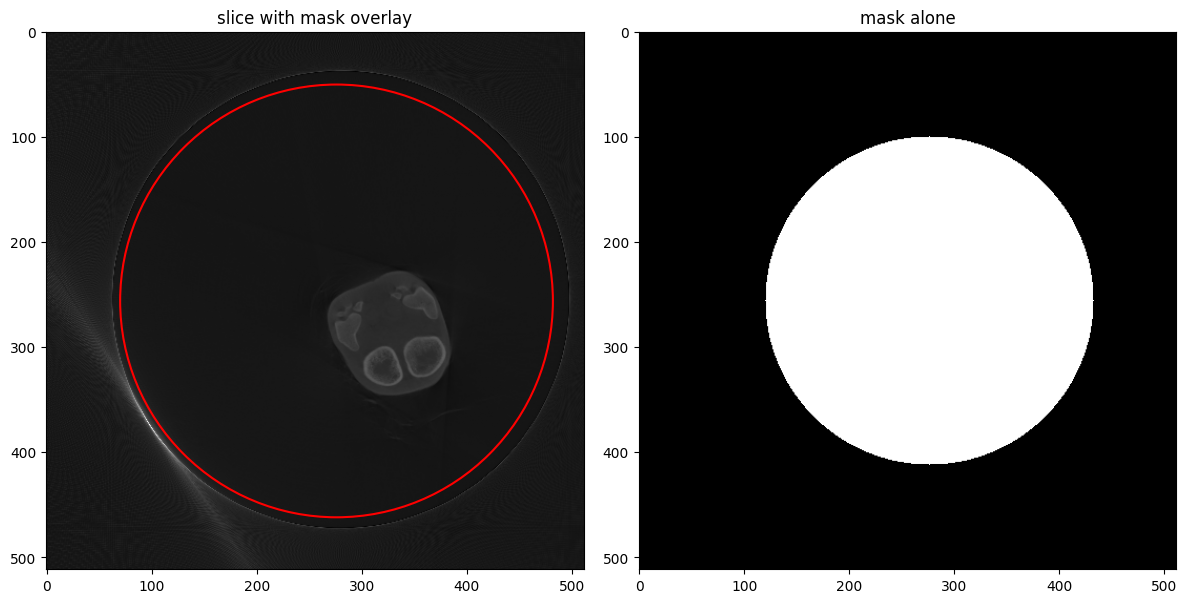

Processed slice 1/300
Processed slice 101/300
Processed slice 201/300
All 300 slices masked
Saved to: C:\user\setting\device_D001_1769156028354\CT_new.mha


In [75]:
import SimpleITK as sitk
import cv2
import numpy as np
import matplotlib.pyplot as plt

original_image = sitk.ReadImage(r"C:\user\setting\device_D001_1769156028354\CT.mha")
original_array = sitk.GetArrayFromImage(original_image)
ct0 = original_array.copy()

print(f"Volume shape (Z, Y, X): {ct0.shape}")

# ============================================================
# 1. 只用一个切片检测圆，生成一个统一的 mask
# ============================================================
sample_slice = ct0[ct0.shape[0] // 2, :, :]  # 取中间层
slice_512 = cv2.resize(sample_slice, (512, 512))

img = cv2.normalize(slice_512, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
img_blur = cv2.medianBlur(img, 5)

h, w = img.shape

circles = cv2.HoughCircles(
    img_blur, cv2.HOUGH_GRADIENT, dp=1.2, minDist=100,
    param1=100, param2=50,
    minRadius=50, maxRadius=700
)

if circles is not None:
    circles = np.uint16(np.around(circles))
    cx, cy, r_inner = circles[0][0]
    print(f"检测到圆心: ({cx}, {cy}), 水模体半径: {r_inner}")
else:
    print("未检测到圆，使用默认值")
    cx, cy = (w// 2 )+20, (h// 2 )
    r_inner = min(w, h) // 2

# 创建统一的水区域 mask
yy, xx = np.ogrid[:h, :w]
dist_from_center = np.sqrt((xx - cx)**2 + (yy - cy)**2)
water_outer_radius = r_inner - 100
reliable_water_mask = (dist_from_center <= water_outer_radius)

print(f"水区域 mask 形状: {reliable_water_mask.shape}, 非零像素数: {np.sum(reliable_water_mask)}")

# 可视化：原图 + mask
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(img, cmap='gray')
circle_outer = plt.Circle((cx, cy), r_inner - 50, fill=False, color='r', linewidth=1.5)
axes[0].add_patch(circle_outer)
axes[0].set_title('slice with mask overlay')

axes[1].imshow(reliable_water_mask, cmap='gray')
axes[1].set_title('mask alone')

plt.tight_layout()
plt.show()

# ============================================================
# 2. 所有层套用同一个 mask
# ============================================================
orig_h, orig_w = sample_slice.shape
mask_bool = cv2.resize(reliable_water_mask.astype(np.uint8), (orig_w, orig_h)).astype(bool)

for z in range(ct0.shape[0]):
    ct0[z, :, :][~mask_bool] = 0
    if z % 100 == 0:
        print(f"Processed slice {z+1}/{ct0.shape[0]}")

print(f"All {ct0.shape[0]} slices masked")

# ============================================================
# 3. 保存为 MHD
# ============================================================
output = sitk.GetImageFromArray(ct0)
output.SetSpacing(original_image.GetSpacing())
output.SetOrigin(original_image.GetOrigin())
output.SetDirection(original_image.GetDirection())

output_path = r"C:\user\setting\device_D001_1769156028354\CT_new.mha"
sitk.WriteImage(output, output_path)
print(f"Saved to: {output_path}")